<a href="https://colab.research.google.com/github/034adarsh/Stock-Price-Prediction-Using-LSTM/blob/main/LSTM_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import all the required libraries

---



In [49]:
import pandas as pd
import datetime as dt
from datetime import date
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf

# Define start day to fetch the dataset from the yahoo finance library

---



In [50]:


START = "2015-01-01"
TODAY = date.today().strftime("%Y-%m-%d")

# Define a function to load the dataset

def load_data(ticker):
    data = yf.download(ticker, START, TODAY)
    data.reset_index(inplace=True)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    return data

In [51]:
data = load_data('AAPL')
df=data
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.214891,24.682224,23.776352,24.671149,212818400
1,2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2,2015-01-06,23.534937,23.794073,23.173916,23.596952,263188400
3,2015-01-07,23.864954,23.964621,23.632395,23.743137,160423600
4,2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000


In [52]:
df = df.drop(['Date', 'Adj Close'], axis=1, errors='ignore')
df.head()

Price,Close,High,Low,Open,Volume
0,24.214891,24.682224,23.776352,24.671149,212818400
1,23.532722,24.064285,23.346676,23.984551,257142000
2,23.534937,23.794073,23.173916,23.596952,263188400
3,23.864954,23.964621,23.632395,23.743137,160423600
4,24.781893,24.839479,24.075357,24.192745,237458000


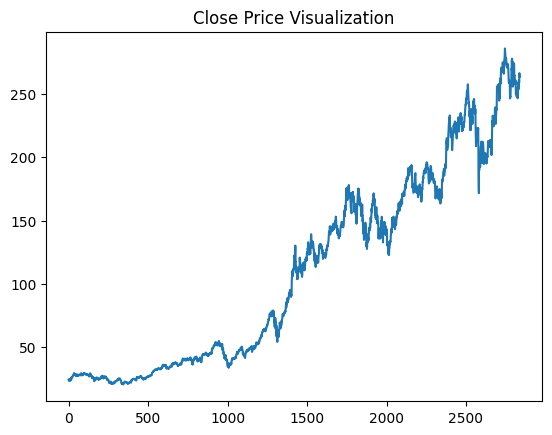

In [53]:
plt.title("Close Price Visualization")
plt.plot(df.Close)

In [54]:
df

Price,Close,High,Low,Open,Volume
0,24.214891,24.682224,23.776352,24.671149,212818400
1,23.532722,24.064285,23.346676,23.984551,257142000
2,23.534937,23.794073,23.173916,23.596952,263188400
3,23.864954,23.964621,23.632395,23.743137,160423600
4,24.781893,24.839479,24.075357,24.192745,237458000
...,...,...,...,...,...
2833,260.480011,262.190002,259.019989,259.980011,31291500
2834,259.200012,260.179993,256.660004,259.730011,36234700
2835,258.829987,261.929993,257.190002,259.250000,48370700
2836,266.429993,266.559998,257.809998,258.160004,49735000


# Plotting moving averages of 100 day

---



In [55]:
ma100 = df.Close.rolling(100).mean()
ma100

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
2833    264.664138
2834    264.534584
2835    264.450785
2836    264.443185
2837    264.395395
Name: Close, Length: 2838, dtype: float64

Text(0.5, 1.0, 'Graph Of Moving Averages Of 100 Days')

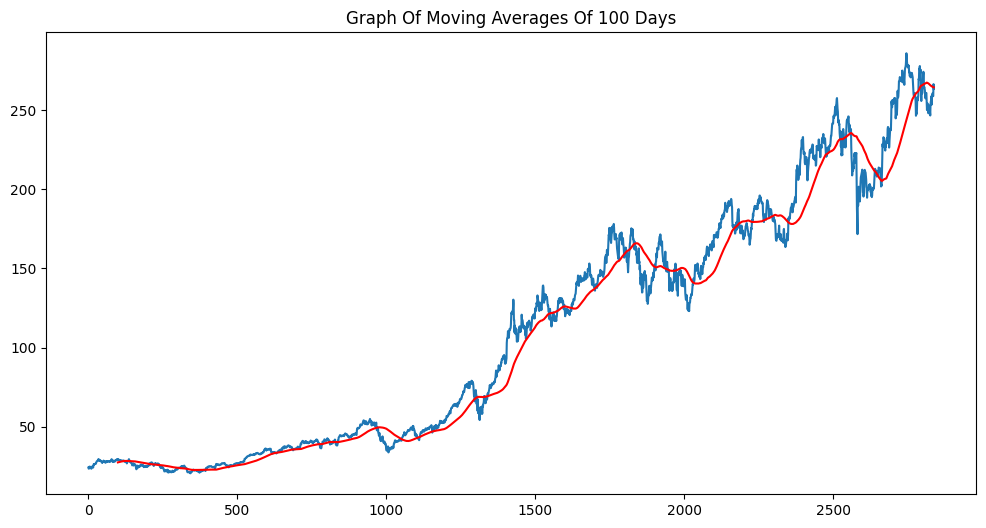

In [56]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.title('Graph Of Moving Averages Of 100 Days')

# Defining 200 days moving averages and plotting comparision graph with 100 days moving averages

---



In [57]:
ma200 = df.Close.rolling(200).mean()
ma200

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
2833    250.305112
2834    250.596369
2835    250.888568
2836    251.218368
2837    251.513281
Name: Close, Length: 2838, dtype: float64

Text(0.5, 1.0, 'Comparision Of 100 Days And 200 Days Moving Averages')

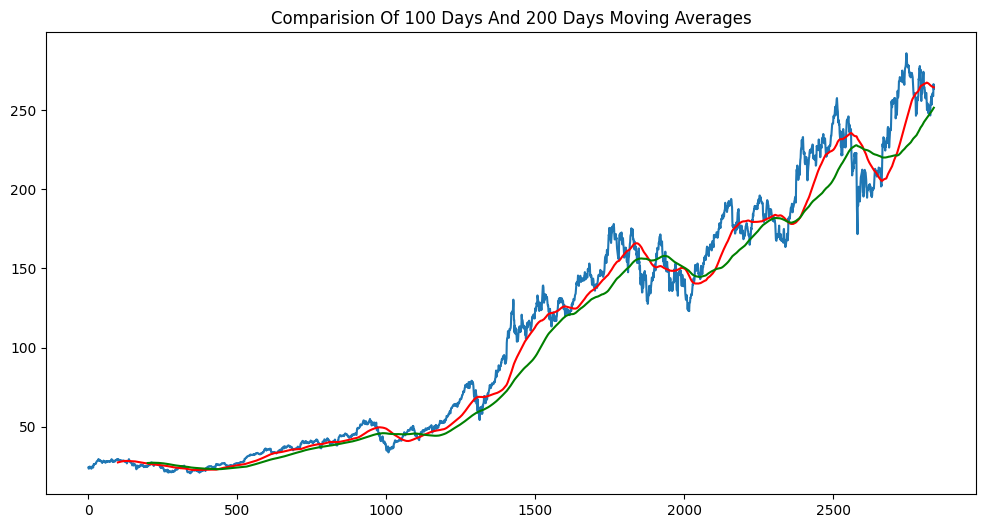

In [58]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')
plt.title('Comparision Of 100 Days And 200 Days Moving Averages')

In [59]:
df.shape

(2838, 5)

# Spliting the dataset into training (70%) and testing (30%) set

In [60]:
# Splitting data into training and testing

train = pd.DataFrame(data[0:int(len(data)*0.70)])
test = pd.DataFrame(data[int(len(data)*0.70): int(len(data))])

print(train.shape)
print(test.shape)

(1986, 6)
(852, 6)


In [61]:
train.head()

Price,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.214891,24.682224,23.776352,24.671149,212818400
1,2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2,2015-01-06,23.534937,23.794073,23.173916,23.596952,263188400
3,2015-01-07,23.864954,23.964621,23.632395,23.743137,160423600
4,2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000


In [62]:
test.head()

Price,Date,Close,High,Low,Open,Volume
1986,2022-11-21,145.673950,147.996703,145.388534,147.790026,58724100
1987,2022-11-22,147.809692,148.045910,144.610987,145.792060,51804100
1988,2022-11-23,148.685684,149.433684,146.982978,147.091242,58301400
1989,2022-11-25,145.772385,146.530236,144.798004,145.969225,35195900
1990,2022-11-28,141.943787,144.325590,141.117048,142.849265,69246000


# Using MinMax scaler for normalization of the dataset

---



In [63]:
try:
    from sklearn.preprocessing import MinMaxScaler
except ModuleNotFoundError as err:
    raise ModuleNotFoundError(
        "scikit-learn is required but not installed in this notebook kernel. "
        "Install it with `pip install scikit-learn` in the active environment and restart the kernel."
    ) from err

scaler = MinMaxScaler(feature_range=(0,1))


In [64]:
train_close = train.iloc[:, 4:5].values
test_close = test.iloc[:, 4:5].values

In [65]:
data_training_array = scaler.fit_transform(train_close)
data_training_array

array([[0.02631933],
       [0.02197935],
       [0.01952935],
       ...,
       [0.79814505],
       [0.78134769],
       [0.8179286 ]], shape=(1986, 1))

In [66]:
x_train = []
y_train = [] 

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train) 

In [67]:
x_train.shape

(1886, 100, 1)

# ML Model (LSTM)

---



In [68]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [69]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences=True
              ,input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))


model.add(LSTM(units = 60, activation = 'relu', return_sequences=True))
model.add(Dropout(0.3))


model.add(LSTM(units = 80, activation = 'relu', return_sequences=True))
model.add(Dropout(0.4))


model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

c:\Users\amarj\Desktop\StockPricePrediction\Stock-Price-Prediction-Using-LSTM\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [70]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

# Training the model

---



In [71]:
past_100_days = pd.DataFrame(train_close[-100:])

In [72]:
test_df = pd.DataFrame(test_close)

**Defining the final dataset for testing by including last 100 coloums of the training dataset to get the prediction from the 1st column of the testing dataset.**

---


In [73]:
final_df = pd.concat([past_100_days, test_df], ignore_index=True)


In [74]:
final_df.head()

,0
0,134.673002
1,133.485720
2,135.183237
3,138.695998
4,140.599584


In [75]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.06578806],
       [0.05845514],
       [0.06893938],
       [0.09063497],
       [0.10239194],
       [0.11433084],
       [0.11681537],
       [0.1173606 ],
       [0.10057392],
       [0.10717947],
       [0.14172328],
       [0.14754112],
       [0.13045103],
       [0.14984377],
       [0.17032732],
       [0.17572119],
       [0.16735783],
       [0.15675256],
       [0.15869182],
       [0.18535692],
       [0.21117361],
       [0.20977973],
       [0.2042648 ],
       [0.20874949],
       [0.24008103],
       [0.22448632],
       [0.24366319],
       [0.22940186],
       [0.25161323],
       [0.26605662],
       [0.26460017],
       [0.27491707],
       [0.28256342],
       [0.28250291],
       [0.28844986],
       [0.28408057],
       [0.26381135],
       [0.24797201],
       [0.24942846],
       [0.25828886],
       [0.26915165],
       [0.21198482],
       [0.21793203],
       [0.20688713],
       [0.18461496],
       [0.20348868],
       [0.18358337],
       [0.173

In [76]:
input_data.shape

(952, 1)

# Testing the model

---



In [77]:
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
   x_test.append(input_data[i-100: i])
   y_test.append(input_data[i, 0])

In [78]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(852, 100, 1)
(852,)


In [79]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['MAE'])
model.fit(x_train, y_train, validation_data = (x_test, y_test) ,epochs = 50)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 28s 280ms/step - MAE: 0.1361 - loss: 0.0438 - val_MAE: 0.0805 - val_loss: 0.0097
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 235ms/step - MAE: 0.0596 - loss: 0.0081 - val_MAE: 0.0842 - val_loss: 0.0105
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 231ms/step - MAE: 0.0498 - loss: 0.0064 - val_MAE: 0.0571 - val_loss: 0.0050
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 235ms/step - MAE: 0.0462 - loss: 0.0056 - val_MAE: 0.0513 - val_loss: 0.0042
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 236ms/step - MAE: 0.0448 - loss: 0.0051 - val_MAE: 0.0505 - val_loss: 0.0042
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 235ms/step - MAE: 0.0486 - loss: 0.0059 - val_MAE: 0.0505 - val_loss: 0.0042
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 228ms/step - MAE: 0.0451 - loss: 0.0054 - val_MAE: 0.0601 - val_loss: 0.0056
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 235ms/step - MAE: 0.0440 - loss: 0.0047 - val_MAE: 0.0645 - val_loss: 0.0066
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/

KeyboardInterrupt: 

In [ ]:
model.save('keras_model.h5')

In [ ]:

test_close.shape
test_close

# Making prediction and plotting the graph of predicted vs actual values

---



In [80]:
# Making predictions

y_pred = model.predict(x_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step


In [81]:
y_pred.shape

(852, 1)

In [82]:
y_test

array([0.1468017 , 0.13446182, 0.14248586, 0.13555603, 0.11628646,
       0.11111932, 0.09355192, 0.1349482 , 0.1212712 , 0.13227357,
       0.12801839, 0.09835422, 0.09938757, 0.09926599, 0.10145434,
       0.14278978, 0.11756317, 0.09178902, 0.06492106, 0.05531658,
       0.03270371, 0.04236882, 0.05069698, 0.02984678, 0.03264296,
       0.02224831, 0.01203604, 0.01458933, 0.02595627, 0.00534937,
       0.0068082 , 0.        , 0.02711129, 0.02583481, 0.03185278,
       0.04784002, 0.03659415, 0.05361442, 0.06571123, 0.04905555,
       0.05635005, 0.0736135 , 0.08692603, 0.09045171, 0.10431134,
       0.10425046, 0.11519244, 0.10145417, 0.1091743 , 0.13914248,
       0.13385404, 0.16145147, 0.14971957, 0.16941466, 0.16880683,
       0.14393378, 0.15300486, 0.160128  , 0.16615512, 0.1685899 ,
       0.16152809, 0.14843888, 0.14034184, 0.14776929, 0.12962677,
       0.13327975, 0.1292617 , 0.12792211, 0.11300662, 0.13528859,
       0.17029504, 0.16974686, 0.16432867, 0.16889461, 0.14849

In [83]:
y_pred

array([[0.11998054],
       [0.1201631 ],
       [0.12059142],
       [0.12124881],
       [0.12209548],
       [0.12304971],
       [0.12401392],
       [0.12487186],
       [0.12558752],
       [0.12614486],
       [0.12656088],
       [0.1268598 ],
       [0.12702057],
       [0.12701236],
       [0.12680985],
       [0.12640582],
       [0.12587032],
       [0.12525877],
       [0.12457445],
       [0.12377153],
       [0.12280311],
       [0.12162411],
       [0.12018436],
       [0.11847349],
       [0.11635455],
       [0.11365063],
       [0.1102371 ],
       [0.10610175],
       [0.10124928],
       [0.09578031],
       [0.08968654],
       [0.08305787],
       [0.07623574],
       [0.06980061],
       [0.06407148],
       [0.05911605],
       [0.05493358],
       [0.05140487],
       [0.04845053],
       [0.04598033],
       [0.04392182],
       [0.04221853],
       [0.04083174],
       [0.03974167],
       [0.03893952],
       [0.03842508],
       [0.03819588],
       [0.038

In [84]:
scaler.scale_

array([0.00617622])

In [85]:
scale_factor = 1/0.00985902
y_pred = y_pred * scale_factor
y_test = y_test * scale_factor

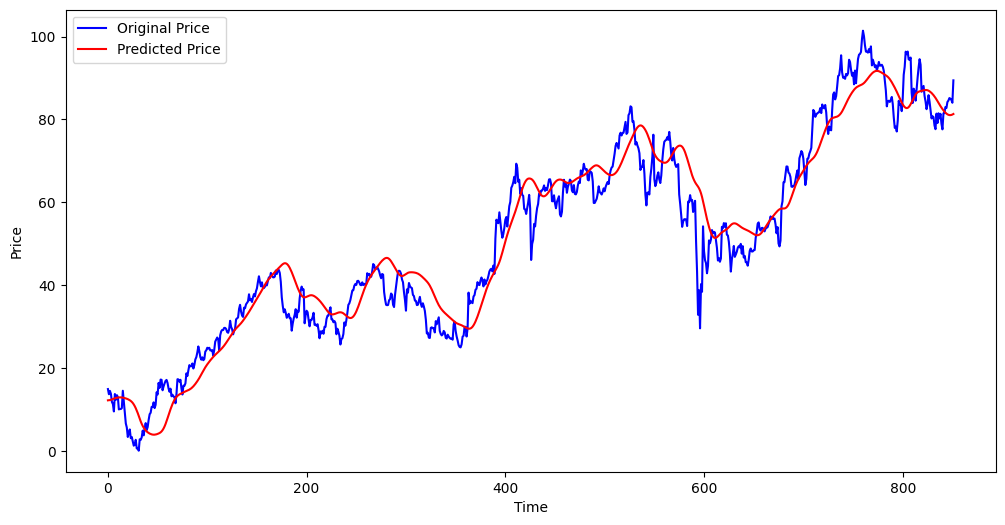

In [86]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_pred, 'r', label = "Predicted Price")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

# Model evaluation

In [87]:
try:
    from sklearn.metrics import mean_absolute_error
except ModuleNotFoundError as err:
    raise ModuleNotFoundError(
        "scikit-learn is required but not installed in this notebook kernel. "
        "Install it with `pip install scikit-learn` in the active environment and restart the kernel."
    ) from err
